### Init

In [1]:
import sys
sys.path.append('../src/')

In [2]:
from constants import INPT_VARS, EXTRA_VARS, OUT_VARS, GLOBAL_COMBINED_STATS
import hydra
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import logging

from utils.data_utils import (
    get_wet_mask,
    get_train_test_ranges,
    gen_data_in_test,
    gen_data_out_test,
    data_CNN_Lateral,
    data_CNN_Dynamic,
    gen_data_025_lateral,
    gen_data_global_new,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_mean,
    compute_var,
    compute_corrs_area,
    compute_rmse,
    compute_corrs,
    compute_KE,
    compute_time_spec,
    compute_ACC,
    compute_nino34,
    compute_amo,
    gen_KE_spectrum,
    gen_KE,
    gen_KE_range,
    gen_value_range,
    gen_enstrophy_spectrum,
    gen_enstrophy,
    compute_corrs_single,
    compute_ACC_single,
    compute_RMSE_single,
    compute_mean_single,
)
from utils.subgrid_utils import get_area_tensor
from utils.climate_utils import compute_laplacian_wet
from utils.plot_utils import (
    plot_short_time_stats,
    plot_long_time_stats,
    plot_map,
    plot_error_map,
    plot_both_error_map,
    plot_metrics_KE_spectrum,
    plot_metrics_KE,
    plot_metrics_enstrophy_spectrum,
    plot_metrics_entrophy,
    plot_metrics_corr,
    plot_metrics_rmse,
    plot_metrics_acc,
    plot_metrics_mean,
    plot_metrics_pdf,
    get_initial_snapshot_fig,
    plot_region_based_metric,
    plot_diff_map,
)

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import copy
from datetime import datetime
import os

In [3]:
class Eval:
    def __init__(self, args):
        # Getting input, extra input and output
        self.inputs = INPT_VARS[args.exp_num_in]
        self.extra_in = EXTRA_VARS[args.exp_num_extra]
        self.outputs = OUT_VARS[args.exp_num_out]

        self.str_in = "".join([i + "_" for i in self.inputs])
        self.str_ext = "".join([i + "_" for i in self.extra_in])
        self.str_out = "".join([i + "_" for i in self.outputs])

        print("inputs: " + self.str_in)
        print("extra inputs: " + self.str_ext)
        print("outputs: " + self.str_out)

        self.N_atm = len(self.extra_in)  # Number of atmosphere variables
        self.N_in = len(self.inputs)
        if args.lateral:
            self.N_extra = (
                self.N_atm + self.N_in
            )  # Number of atmosphere variables + Lateral boundary variables
        else:
            self.N_extra = self.N_atm  # Number of atmosphere variables
        self.N_out = len(self.outputs)

        self.num_in = int((args.hist + 1) * self.N_in + self.N_extra)

        print("Number of inputs: ", self.num_in)  # 3 (ocean speeds + ocean temp)(t) +
        # 3 (atm wind stresses + atm temp)(t) +
        # 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
        print("Number of outputs: ", self.N_out)  # 3

        # Post-fix strings
        self.str_train = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_out
            + "N_train_4000"
            + "_Lateral_Data_025_no_smooth"
        )
        self.str_save = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_"
            + args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )
        self.post_model_name = (
            "Train_" + args.train_region
            + "_Test_" + args.region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_in
            + "N_train_"
            + str(args.N_samples)
            + "_Lateral_Data_025_no_smooth"
        )
        self.post_pred_name = (
            args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )

        # Getting start and end indices of train and test
        s_train, e_train, e_test = get_train_test_ranges(
            args.N_samples, args.N_val, args.lag, args.hist, args.interval
        )

        # Saving data
        print("Getting inputs")
        if "global_1" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag)
        elif "global_2x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="2x")
        elif "global_4x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="4x")
        else:
            raise NotImplementedError

        print("Calculating mask tensors")
        self.wet, self.wet_nan = get_wet_mask(inputs, "cpu")
        self.wet_bool = np.array(self.wet.cpu()).astype(bool)
        wet_lap = compute_laplacian_wet(self.wet_nan, 4) # hardcoded
        wet_lap = xr.where(wet_lap == 0, 1, np.nan)
        self.wet_lap = np.nan_to_num(wet_lap)
        print("Wet resolution:", self.wet.shape)

        self.time_vec = inputs[0].time.data

        self.time_test = self.time_vec[e_test : (e_test + args.lag * args.N_test)]

        print("Loading Train data")
        train_data = torch.load(
                    Path(args.data_dir) / "train_data_cnn_{0}.pt".format(self.str_train),
                    map_location=torch.device("cpu"),
                )
        self.train_data = train_data
    
        if args.save_test_data:
            print("Saving data")
            data_in_test = gen_data_in_test(
                0, e_test, args.N_test, args.lag, args.hist, inputs, extra_in
            )
            data_out_test = gen_data_out_test(
                0, e_test, args.N_test, args.lag, args.hist, outputs
            )
            if "global" in args.region:
                norm_vals = train_data.norm_vals
                if "combined" in args.train_region:
                    assert len(norm_vals) == len(GLOBAL_COMBINED_STATS) and all(np.array_equal(norm_vals[k], GLOBAL_COMBINED_STATS[k]) for k in norm_vals)
                self.test_data = data_CNN_Dynamic(
                    data_in_test,
                    data_out_test,
                    self.wet.to(device="cpu"),
                    norm_vals,
                    device=args.device,
                )
                # del train_data
            else:
                raise NotImplementedError()
            torch.save(
                self.test_data,
                Path(args.data_dir) / "test_data_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading test data")
            self.test_data = torch.load(
                Path(args.data_dir) / "test_data_cnn_{0}.pt".format(self.str_save)
            )

        # Model
        print("Loading model " + args.network)
        if "swin" in args.network.lower():
            model = instantiate(
                args.swin,
                in_channels=self.num_in,
                output_channels=self.N_in,
                pretrain_img_size=[*self.test_data[0][0].shape[1:]],
                wet=self.wet.cuda()
            )
        elif "unet" in args.network.lower():
            model = instantiate(
                args.unet, wet=self.wet.cuda()
            )

        full_model_path = args.ckpt_path
        self.full_model_name = args.network + "_" + self.post_model_name
        self.output_channels = model.output_channels

        model = model.to(args.device)
        self.ckpt_path = args.ckpt_path
        self.model = model

        # Stats
        self.mean_out = self.test_data.norm_vals["m_out"]
        self.std_out = self.test_data.norm_vals["s_out"]
        self.mean_in = self.test_data.norm_vals["m_in"]
        self.std_in = self.test_data.norm_vals["s_in"]

        # clim
        self.clim = None
        if args.save_clim_data:
            print("Saving clim")
            clim = np.zeros((366, *self.wet.shape, 3))
            for i in range(self.N_out):
                clim[:, :, :, i] = (
                    outputs[i].groupby("time.dayofyear").mean("time").data
                )
            torch.save(
                clim,
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading clim")
            clim = torch.load(
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save)
            )

        self.clim = clim

        # Getting area tensor
        print("Computing area tensor")
        self.grids = xr.open_dataset('/scratch/as15415/Data/CM2x_grids/Grid_New.nc').rename({"dx": "dxu", "dy": "dyu"})

        self.area = torch.from_numpy(self.grids["area_C"].to_numpy()).to(device="cpu")
        self.dx = self.grids["dxu"].to_numpy()
        self.dy = self.grids["dyu"].to_numpy()

        self.pred_model_path = Path(args.path_dir) / self.full_model_name
        if not os.path.isdir(self.pred_model_path):
            os.makedirs(self.pred_model_path)

        self.Nb = args.Nb
        self.hist = args.hist
        self.lag = args.lag
        self.N_test = args.N_test
        self.N_samples = args.N_samples
        self.output_dir = args.output_dir
        self.region = args.region
        self.steps = args.steps
        self.network = args.model_name_replace
        self.inputs = inputs

        self.pred_region = args.region
        self.pred_names = args.pred_names if args.pred_names else []
        self.pred_paths = args.pred_paths if args.pred_paths else []

        self.JUPYTER_MODE = False

    def send_data_to_cpu(self):
        self.test_data.set_device(device="cpu")

### G1, G1

In [4]:
# G1, G1
# ConvNext UNet
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_conv_multiseed_g1g1".format(str(datetime.now())[:10]),
        "model_name_replace=ConvNext UNet",
        "train_region=global_1",
        "region=global_1",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=ConvNext UNet Train1Eval1",
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed100/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed200/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=null",
        "pred_paths=null"
    ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# Adam UNet
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_adamunet_global", overrides=[
#         "output_dir=./temp/{0}_adam_multiseed_g1g1".format(str(datetime.now())[:10]),
#         "model_name_replace=Adam UNet",
#         "train_region=global_1",
#         "region=global_1",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=Adam UNet Train1Eval1",
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-13-foundation_train_adamunet_global_1/adamunetseed/saved_nets/adamunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_seed100/daam/saved_nets/adamunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_seed200/adam/saved_nets/adamunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# Swin
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_swin_global", overrides=[
#         "output_dir=./temp/{0}_swin_multiseed_g1g1".format(str(datetime.now())[:10]),
#         "model_name_replace=Swin",
#         "train_region=global_1",
#         "region=global_1",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=Swin Train1Eval1",
#         "swin.embed_dim=60",
#         "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
#         "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_swintrans60_global_1/swintrans60/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_seed100/swin/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_seed200/swin/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=['UNet (Baseline)', 'ConvNext UNet']",
#         "pred_paths=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/Adam UNet Train1Eval1_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth]"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model ConvNext UNet Train1Eval1
Loading clim
Computing area tensor


### G1, G2x

In [4]:
# ConvNext UNet
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_conv_multiseed_g1g2x".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet",
#         "train_region=global_1",
#         "region=global_2x",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=ConvNext UNet Train1Eval2x",
        # "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
        #             /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed100/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
        #             /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed200/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# Adam UNet
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_adamunet_global", overrides=[
#         "output_dir=./temp/{0}_adam_multiseed_g1g2x".format(str(datetime.now())[:10]),
#         "model_name_replace=Adam UNet",
#         "train_region=global_1",
#         "region=global_2x",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=Adam UNet Train1Eval2x",
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-13-foundation_train_adamunet_global_1/adamunetseed/saved_nets/adamunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_seed100/daam/saved_nets/adamunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_seed200/adam/saved_nets/adamunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# Swin
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_swin_global", overrides=[
#         "output_dir=./temp/{0}_swin_multiseed_g1g2x".format(str(datetime.now())[:10]),
#         "model_name_replace=Swin",
#         "train_region=global_1",
#         "region=global_2x",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=Swin Train1Eval2x",
#         "swin.embed_dim=60",
#         "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
#         "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_swintrans60_global_1/swintrans60/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_seed100/swin/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_seed200/swin/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=['UNet (Baseline)', 'ConvNext UNet']",
#         "pred_paths=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/Adam UNet Train1Eval2x_Train_global_1_Test_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval2x_Train_global_1_Test_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth]"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model Swin Train1Eval2x


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading clim
Computing area tensor


### G1_2x, G_4x

In [4]:
# ConvNext UNet
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_conv_multiseed_g12x_g4x".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet",
#         "train_region=combined_global_1",
#         "region=global_4x",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "network=ConvNext UNet Train12xEval4x",
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-13-foundation_train_convnextunet_global_1_2x/convnext/saved_nets/convnextunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_2x_seed100/convnext/saved_nets/convnextunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_2x_seed200/convnext/saved_nets/convnextunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# Adam UNet
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_adamunet_global", overrides=[
#         "output_dir=./temp/{0}_adam_multiseed_g12x_g4x".format(str(datetime.now())[:10]),
#         "model_name_replace=Adam UNet",
#         "train_region=combined_global_1",
#         "region=global_4x",
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=Adam UNet Train12xEval4x",
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-13-foundation_train_adamunet_global_1_2x/adam/saved_nets/adamunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_2x_seed100/adam/saved_nets/adamunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_2x_seed200/adam/saved_nets/adamunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# Swin
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_swin_global", overrides=[
        "output_dir=./temp/{0}_swin_multiseed_g12x_g4x".format(str(datetime.now())[:10]),
        "model_name_replace=Swin",
        "train_region=combined_global_1",
        "region=global_4x",
        "N_samples=0",
        "N_val=0",
        "N_test=2000",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=Swin Train12xEval4x",
        "swin.embed_dim=60",
        "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
        "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-13-foundation_train_swin_global_1_2x/foundationswin/saved_nets/swin_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_2x_seed100/swin/saved_nets/swin_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_2x_seed200/swin/saved_nets/swin_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['UNet (Baseline)', 'ConvNext UNet']",
        "pred_paths=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/Adam UNet Train12xEval4x_Train_combined_global_1_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train12xEval4x_Train_combined_global_1_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth]"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model Swin Train12xEval4x


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading clim
Computing area tensor


### G1 (7k), G4x Test - ConvNext

In [36]:
# ConvNext UNet - 7k
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_conv_multiseed_g17kg4x".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet",
#         "train_region=global_1",
#         "region=global_4x",
#         "save_test_data=False", # Done Generation
#         "save_clim_data=False", # Done Generation
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=ConvNext UNet Train17kEval4x",
#         "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-22-foundation_train_convnextunet_global_1_7k_seed10/cn/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_7000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-22-foundation_train_convnextunet_global_1_7k_seed100/cn/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_7000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-22-foundation_train_convnextunet_global_1_7k_seed200/cn/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_7000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# ConvNext UNet - 4k
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_conv_multiseed_g1g4x".format(str(datetime.now())[:10]),
        "model_name_replace=ConvNext UNet 4k",
        "train_region=global_1",
        "region=global_4x",
        "save_test_data=False", # Done Generation
        "save_clim_data=False", # Done Generation
        "N_samples=0",
        "N_val=0",
        "N_test=2000",
        "run_gen_pred=True", # Multi-Seed Generation
        "network=ConvNext UNet Train1Eval4x",
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed100/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed200/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['ConvNext UNet 7k']",
        "pred_paths=['/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train17kEval4x_Train_global_1_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth']"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)


e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs
Calculating mask tensors


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model ConvNext UNet Train1Eval4x
Loading clim
Computing area tensor


### G1 Preloaded, G2x Trained, G4x Test - ConvNext

#### Old

In [ ]:
# 50%
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_convnext_blends".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet 50%",
#         "network=ConvNext UNet Preload1Train2xEval4x50",
#         "train_region=global_2x",
#         "region=global_4x",
#         "save_test_data=False", # Done Generation
#         "save_clim_data=False", # Done Generation
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "run_gen_pred=False", # Done Generation
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_50p/cnext/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# 10%
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_convnext_blends".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet 10%",
#         "network=ConvNext UNet Preload1Train2xEval4x10",
#         "train_region=global_2x",
#         "region=global_4x",
#         "save_test_data=False", # Done Generation
#         "save_clim_data=False", # Done Generation
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "run_gen_pred=False", # Done Generation
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_10p/connext/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

#### Use

In [10]:
# 25%
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_convnext_blends".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet 25%",
#         "network=ConvNext UNet Preload1Train2xEval4x25",
#         "train_region=global_2x",
#         "region=global_4x",
#         "save_test_data=False", # Done Generation
#         "save_clim_data=False", # Done Generation
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "run_gen_pred=False", # Done Generation
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_25p/cnext/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_25p_seed100/per/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_25p_seed200/200/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# 5%
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_convnext_blends".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet 5%",
#         "network=ConvNext UNet Preload1Train2xEval4x05",
#         "train_region=global_2x",
#         "region=global_4x",
#         "save_test_data=False", # Done Generation
#         "save_clim_data=False", # Done Generation
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "run_gen_pred=False", # Done Generation
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_05p/percent/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_05p_seed100/5/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_05p_seed200/5/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# 1%
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_convnext_blends_1p_seeds".format(str(datetime.now())[:10]),
        "model_name_replace=1% 2x CO2",
        "network=ConvNext UNet Preload1Train2xEval4x01",
        "train_region=global_2x",
        "region=global_4x",
        "save_test_data=False", # Done Generation
        "save_clim_data=False", # Done Generation
        "N_samples=0",
        "N_val=0",
        "N_test=2000",
        "run_gen_pred=False", # Done Generation
        "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p/1p/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p_seed100/1/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p_seed200/1/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['0% 2x CO2', '25% 2x CO2', '5% 2x CO2']",
        "pred_paths=['/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval4x_Train_global_1_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Preload1Train2xEval4x25_Train_global_2x_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Preload1Train2xEval4x05_Train_global_2x_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth']"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs
Calculating mask tensors


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model ConvNext UNet Preload1Train2xEval4x01
Loading clim
Computing area tensor


#### Fixed

In [11]:
# 25%
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_convnext_blends_fixed".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet 25%",
#         "network=ConvNext UNet Preload1Train2xEval4x_Fixed_25",
#         "train_region=global_2x",
#         "region=global_4x",
#         "save_test_data=False", # Done Generation
#         "save_clim_data=False", # Done Generation
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "run_gen_pred=True", # Done Generation
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_25p/cnext/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_25p_seed100/per/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_25p_seed200/200/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# 5%
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_convnext_blends_fixed".format(str(datetime.now())[:10]),
#         "model_name_replace=ConvNext UNet 5%",
#         "network=ConvNext UNet Preload1Train2xEval4x_Fixed_05",
#         "train_region=global_2x",
#         "region=global_4x",
#         "save_test_data=False", # Done Generation
#         "save_clim_data=False", # Done Generation
#         "N_samples=0",
#         "N_val=0",
#         "N_test=2000",
#         "run_gen_pred=True", # Done Generation
#         "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_05p/percent/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_05p_seed100/5/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_05p_seed200/5/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# 1%
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_convnext_blends_fixed_1p_seeds".format(str(datetime.now())[:10]),
        "model_name_replace=1% 2x CO2",
        "network=ConvNext UNet Preload1Train2xEval4x_Fixed_01",
        "train_region=global_2x",
        "region=global_4x",
        "save_test_data=False", # Done Generation
        "save_clim_data=False", # Done Generation
        "N_samples=0",
        "N_val=0",
        "N_test=2000",
        "run_gen_pred=True", # Done Generation
        "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p/1p/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p_seed100/1/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p_seed200/1/saved_nets/convnextunet_epoch_100_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['0% 2x CO2', '25% 2x CO2', '5% 2x CO2']",
        "pred_paths=['/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval4x_Train_global_1_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Preload1Train2xEval4x_Fixed_25_Train_global_2x_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Preload1Train2xEval4x_Fixed_05_Train_global_2x_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth']"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model ConvNext UNet Preload1Train2xEval4x_Fixed_01
Loading clim
Computing area tensor


### G2

In [22]:
# G2x G4x
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_convnext_g2x_g4x".format(str(datetime.now())[:10]),
        "model_name_replace=2x CO2",
        "network=ConvNext UNet Train2xEval4x",
        "train_region=global_2x",
        "region=global_4x",
        "save_test_data=False", # Done Generation
        "save_clim_data=False", # Done Generation
        "N_samples=0",
        "N_val=0",
        "N_test=2000",
        "run_gen_pred=False", # Done Generation
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-13-foundation_train_convnextunet_global_2x/conv/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_2x_seed100/conv/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_2x_seed200/conv/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['0% 2x CO2', '1% 2x CO2', '5% 2x CO2']",
        "pred_paths=['/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval4x_Train_global_1_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Preload1Train2xEval4x01_Train_global_2x_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Preload1Train2xEval4x05_Train_global_2x_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth']"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model ConvNext UNet Train2xEval4x
Loading clim
Computing area tensor


### Generation

In [8]:
def generate_pred_lateral(e):
    print("Generation Pred begin...")
    ns = 4000
    for rand_ind, model_path in enumerate(args.ckpt_path):
        print("Random seed: ", rand_ind+1)
        e.model.load_state_dict(
            torch.load(model_path, map_location=torch.device('cuda'))
        )
        
        model_pred = generate_model_rollout(
            e.N_test,
            e.test_data,
            e.model,
            e.hist,
            e.N_in,
            e.N_extra,
            e.Nb,
            e.region,
        )

        print("data_gen")
        da = xr.DataArray(
            data=model_pred,
            dims=["time", "x", "y", "var"],
        )

        da.to_zarr(
            e.pred_model_path
            / (
                "Pred_lateral_Fast_Data_025_"
                + e.post_pred_name
                + "_rand_seed_"
                + str(rand_ind+1)
                + ".zarr"
            ),
            mode="w",
        )
        print(f"Model pred shape {model_pred.shape}")


In [9]:
if e.run_gen_pred:
    generate_pred_lateral(e)


Generation Pred begin...
Random seed:  1
[[-0.  0. -0. -0. -0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
data_gen
Model pred shape (2000, 180, 360, 3)
Random seed:  2
[[-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]]
data_gen
Model pred shape (2000, 180, 360, 3)
Random seed:  3
[[ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]]
data_gen
Model pred shape (2000, 180, 360, 3)


### Loading and Plotting

In [23]:
num_seeds = 3

In [24]:
e.send_data_to_cpu()

def load_seeded_data(Pred_path, e, current_net=False):
    if current_net:
        prefix =  "Pred_lateral_Fast_Data_025_" + e.post_pred_name + "_rand_seed_"
    else:
        prefix = ("Pred_lateral_Fast_Data_025_" 
                    + e.pred_region
                    + "_in_"
                    + e.str_in
                    + "ext_"
                    + "tau_u_tau_v_t_ref_"
                    + "N_samples_"
                    + str(e.N_samples)
                    + "_rand_seed_")

    model_preds = None

    for rand_seed in range(1, num_seeds + 1):
        print("Loading seed ", rand_seed)
        model_pred_net = (
            xr.open_zarr(
                Path(Pred_path) / (prefix + str(rand_seed) + ".zarr")
            )
        ).to_array().to_numpy().squeeze()
    
        if model_preds is None:
            model_preds = np.zeros((num_seeds,) + model_pred_net.shape)
    
        model_preds[rand_seed - 1] = model_pred_net
    
    return model_preds


def load_long_data(e):
    print("Load long data...")
    model_pred_net = load_seeded_data(e.pred_model_path, e, True)

    model_pred_saved_nets = []
    if len(e.pred_paths) > 0:
        for model_pred_path in e.pred_paths:
            model_pred_saved_nets.append(
                load_seeded_data(model_pred_path, e, False)
            )
        
    return model_pred_net, model_pred_saved_nets


In [25]:
model_pred_net, model_pred_saved_nets = load_long_data(e)

Load long data...
Loading seed  1
Loading seed  2
Loading seed  3
Loading seed  1
Loading seed  2
Loading seed  3
Loading seed  1
Loading seed  2
Loading seed  3
Loading seed  1
Loading seed  2
Loading seed  3


#### Maps

In [18]:
def compute_corr_map(e, area_flat, pred, truth):
    cor_KE = (area_flat*pred[e.wet_bool].flatten()*truth[e.wet_bool].flatten()).sum()/np.sqrt((area_flat*pred[e.wet_bool].flatten()**2).sum()*(area_flat*truth[e.wet_bool].flatten()**2).sum())
    return cor_KE

def get_map_data(e, model_pred_net, model_pred_saved_nets, start_map=0, N_plot_map=1000, start_error_map=0, N_plot_error_map=1000, long=False):
    print("Getting MAE KE stats...")

    long_KE_net, long_KE_true = gen_KE_range(
        start_error_map, N_plot_error_map, e.test_data, model_pred_net
    )
    _, long_KE_train_true = gen_KE(1000, e.train_data, model_pred_net)
    mse_KE_net = long_KE_net.mean(axis=0) - long_KE_true.mean(axis=0) # np.sqrt(((long_KE_net - long_KE_true)**2).mean(axis=0))
    diff_KE = long_KE_train_true.mean(axis=0) - long_KE_true.mean(axis=0)

    long_mse_KE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_KE_savedi, _ = gen_KE_range(
            start_error_map, N_plot_error_map, e.test_data, model_pred_saved
        )
        mse_KE_savedi = long_KE_savedi.mean(axis=0) - long_KE_true.mean(axis=0) # np.sqrt(((long_KE_savedi - long_KE_true)**2).mean(axis=0))
        long_mse_KE_saved.append(mse_KE_savedi)
    
    long_KE_true = long_KE_true.mean(0)

    print("Getting temp stats...")

    long_temp_net, long_temp_true = gen_value_range(
        start_error_map, N_plot_error_map, e.test_data, model_pred_net, 2
    )
    _, long_temp_train_true = gen_value_range(0, 1000, e.train_data, model_pred_net, 2)
    # mse_temp_net = np.sqrt(((long_temp_net - long_temp_true)**2).mean(axis=0))
    mse_temp_net = long_temp_net.mean(axis=0) - long_temp_true.mean(axis=0)
    diff_temp = long_temp_train_true.mean(axis=0) - long_temp_true.mean(axis=0)

    long_temp_net = long_temp_net.mean(0)

    long_temp_RMSE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_temp_savedi, _ = gen_value_range(
            start_error_map, N_plot_error_map, e.test_data, model_pred_saved, 2
        )
        # mse_KE_savedi = np.sqrt(((long_temp_savedi - long_temp_true)**2).mean(axis=0))
        mse_KE_savedi = long_temp_savedi.mean(axis=0) - long_temp_true.mean(axis=0)
        long_temp_RMSE_saved.append(mse_KE_savedi)

    long_temp_true = long_temp_true.mean(0)

    return long_KE_true, long_mse_KE_saved + [mse_KE_net], diff_KE, long_temp_true, long_temp_RMSE_saved + [mse_temp_net], diff_temp

    

In [19]:
## we can average the results for maps
model_pred_net_averaged = np.mean(model_pred_net, axis=0)
model_pred_saved_nets_averaged = [np.mean(model_pred, axis=0) for model_pred in model_pred_saved_nets]

In [20]:
if args.N_test == 2000:
    long_KE_true, long_mse_KE_saved, diff_KE, long_temp_true, long_temp_RMSE_saved, diff_temp = get_map_data(e, model_pred_net_averaged, model_pred_saved_nets_averaged, start_map=999, N_plot_map=1999, start_error_map=999, N_plot_error_map=1999, long=True)
else:
    long_KE_true, long_mse_KE_saved, diff_KE, long_temp_true, long_temp_RMSE_saved, diff_temp = get_map_data(e, model_pred_net_averaged, model_pred_saved_nets_averaged, start_map=1999, N_plot_map=2999, start_error_map=1999, N_plot_error_map=2999, long=True)

Getting MAE KE stats...
Getting temp stats...


#### Maps Plotting

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

def plot_error_map(
    network_names,
    region,
    save_str,
    output_dir,
    grids,
    Nb,
    wet_nan,
    long_KE_true,
    long_mse_KEs,
    mode="KE",
    JUPYTER_MODE=False,
):

    plt.style.use("bmh")

    # Long KE
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(
        1,
        len(long_mse_KEs)+1,
        figsize=(14, 5),
        gridspec_kw={
            "width_ratios": [1]*(len(long_mse_KEs)+1),
            "height_ratios": [1],
            "wspace": 0.1,
            "hspace": 0.5,
        },
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    # Ground Truth
    if mode == "KE":
        vmin = 0
        vmax = 100
    elif mode == "TEMP":
        vmin = -2
        vmax = 30

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0].set_title(r"CM2.6", size=15)

    pos = axs[0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.32,
        pos.y0 - 0.08,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    if mode == "KE":
        cbar.set_label(r"KE $( J/m^2 )$", fontsize=15)
    elif mode == "TEMP":
        cbar.set_label(r"$\overline{T}$ $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    # Bias plots
    if mode == "KE":
        vmin = -20
        vmax = 20
    elif mode == "TEMP":
        vmin = -2
        vmax = 2
    
    cmap = cmocean.cm.balance

    for i, long_mse_KE_i in enumerate(long_mse_KEs):
        if long_mse_KE_i is not None:
            if "global" in region:
                plt_n = axs[i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=False,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[i+1].set_title(network_names[i], size=15)

    pos = axs[len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.05,
        pos.y0 - 0.08,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    if mode == "KE":
        cbar.set_label(r"Bias KE $( J/m^2 )$", fontsize=15)
    else:
        cbar.set_label(r"Bias $\overline{T}$ $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)


    region_title = ""

    for i in region:
        if region == "Quiescent_Ext":
            region_title = "South Pacific"
        elif region == "Africa_Ext":
            region_title = "African Cape"
        elif i == "_":
            region_title += " "
        elif i == "E":
            break
        else:
            region_title += i
    region_title = str(region_title)

    # a = fig.suptitle(
    #     r"Mean KE " + region_title + ": $t = " + str(1000) + "$ days ",
    #     fontsize=16,
    # )

    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            Path(output_dir) / ("MSE_" + mode + region + "_" + save_str + ".png"),
            bbox_inches="tight",
        )
        plt.clf()


def plot_both_error_map(network_names,
    region,
    save_str,
    output_dir,
    grids,
    Nb,
    wet_nan,
    long_KE_true,
    long_mse_KEs,
    long_T_true,
    long_mse_Ts,
    JUPYTER_MODE=False):

    plt.style.use("bmh")

    # Long KE
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(
        2,
        len(long_mse_Ts)+1,
        figsize=(20, 5),
        gridspec_kw={
            "width_ratios": [1] * (len(long_mse_Ts)+1),
            "height_ratios": [1, 1],
            "wspace": 0.1,
            "hspace": 0.01,
        },
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    # Ground Truth
    vmin = 0
    vmax = 100

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title(r"CM2.6", size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.32,
        pos.y0,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"KE $( J/m^2 )$", fontsize=15)
    fig.delaxes(cax)

    # Bias plots
    vmin = -20
    vmax = 20
    
    cmap = cmocean.cm.balance

    for i, long_mse_KE_i in enumerate(long_mse_KEs):
        if long_mse_KE_i is not None:
            if "global" in region:
                plt_n = axs[0, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[0, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[0, i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[0, i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=False,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[0, i+1].set_title(network_names[i], size=15)

    pos = axs[0, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.05,
        pos.y0,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Bias KE $( J/m^2 )$", fontsize=15)

    fig.delaxes(cax)
 
    ###### TEMP

    # Ground Truth
    vmin = -2
    vmax = 30

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[1, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[1, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    # axs[1, 0].set_title(r"CM2.6", size=15)

    pos = axs[1, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.32,
        pos.y0 - 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"$\overline{T}$ $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    # Bias plots
    vmin = -2
    vmax = 2
    
    cmap = cmocean.cm.balance

    for i, long_mse_T_i in enumerate(long_mse_Ts):
        if long_mse_T_i is not None:
            if "global" in region:
                plt_n = axs[1, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[1, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[1, i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[1, i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.left_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            # axs[1, i+1].set_title(network_names[i], size=15)

    pos = axs[1, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.05,
        pos.y0 - 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Bias $\overline{T}$ $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            Path(output_dir) / ("MSE_KE_TEMP" + region + "_" + save_str + ".png"),
            bbox_inches="tight",
        )
        plt.clf()

#### Plotting

In [23]:
network_names = e.pred_names + [e.network]
try:    
    swapped_long_mse_KE_saved = [long_mse_KE_saved[0], long_mse_KE_saved[3], long_mse_KE_saved[2], long_mse_KE_saved[1]]
    swapped_long_temp_RMSE_saved = [long_temp_RMSE_saved[0], long_temp_RMSE_saved[3], long_temp_RMSE_saved[2], long_temp_RMSE_saved[1]]
    temp = network_names[1]
    network_names[1] = network_names[-1]
    network_names[-1] = temp
except:
    swapped_long_mse_KE_saved = long_mse_KE_saved
    swapped_long_temp_RMSE_saved = long_temp_RMSE_saved

In [24]:
print("Plotting MAE temp map")
plot_both_error_map(
    network_names,
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    e.grids,
    e.Nb,
    e.wet_nan,
    long_KE_true,
    swapped_long_mse_KE_saved,
    long_temp_true,
    swapped_long_temp_RMSE_saved,
    e.JUPYTER_MODE
)


print("Plotting MAE KE")
plot_error_map(
    network_names,
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    e.grids,
    e.Nb,
    e.wet_nan,
    long_KE_true,
    swapped_long_mse_KE_saved,
    "KE",
    e.JUPYTER_MODE
)

print("Plotting Diff KE")
plot_diff_map(
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    e.grids,
    e.Nb,
    e.wet_nan,
    long_KE_true,
    diff_KE,
    "KE",
    e.JUPYTER_MODE
)

print("Plotting Diff Temp")
plot_diff_map(
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    e.grids,
    e.Nb,
    e.wet_nan,
    long_temp_true,
    diff_temp,
    "TEMP",
    e.JUPYTER_MODE
)

Plotting MAE temp map


/state/partition1/job-46954704/ipykernel_232459/986653346.py:323: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
/state/partition1/job-46954704/ipykernel_232459/986653346.py:391: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt_n, ax=cax, orientation="vertical", aspect=10)
/state/partition1/job-46954704/ipykernel_232459/986653346.py:468: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
/state/partition1/job-46954704/ipykernel_2

Plotting MAE KE


/state/partition1/job-46954704/ipykernel_232459/986653346.py:108: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
/state/partition1/job-46954704/ipykernel_232459/986653346.py:184: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt_n, ax=cax, orientation="vertical", aspect=10)


Plotting Diff KE
Plotting Diff Temp


<Figure size 2000x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [25]:
np.save(Path(args.output_dir) / 'map_long_KE_true', long_KE_true)
np.save(Path(args.output_dir) / 'map_long_temp_true', long_temp_true)
np.save(Path(args.output_dir) / 'map_swapped_long_mse_KE_saved', swapped_long_mse_KE_saved)
np.save(Path(args.output_dir) / 'map_swapped_long_temp_RMSE_saved', swapped_long_temp_RMSE_saved)

#### Timeseries KE

In [11]:
def get_timeseries_KE(e, model_pred_net, model_pred_saved_nets, start=0, N_plot=200, N_plot_spec=200, long=False):
    print("Getting KE stats...")
    
    KE_net_list = []
    KE_true_list = []
    
    for i in range(num_seeds):
        KE_net, KE_true = compute_KE(N_plot, e.test_data, model_pred_net[i], e.area, e.wet_bool)
        KE_net_list.append(KE_net)
        KE_true_list.append(KE_true)
    
    KE_net = np.stack(KE_net_list)
    KE_true = np.stack(KE_true_list)

    KE_saved = []

    for model_pred_saved in model_pred_saved_nets:
        KE_neti = []
        for i in range(num_seeds):
            KE_neti_i, _ = compute_KE(
                N_plot, e.test_data, model_pred_saved[i], e.area, e.wet_bool
            )
            KE_neti.append(KE_neti_i)
        KE_saved.append(np.stack(KE_neti))
    
    return KE_true, KE_saved + [KE_net]

In [12]:
if args.N_test == 2000:
    KE_true, KE_saved = get_timeseries_KE(e, model_pred_net, model_pred_saved_nets, start=999, N_plot=1999, N_plot_spec=1000, long=True)
else:
    KE_true, KE_saved = get_timeseries_KE(e, model_pred_net, model_pred_saved_nets, start=1999, N_plot=2999, N_plot_spec=1000, long=True)

Getting KE stats...


In [17]:
def plot_metrics_KE_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    KE_true,
    KEs,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(KE_true)

    # KE
    rho = 1020
    for i, KE_i in enumerate(KEs):
        if KE_i is not None:
            plt.plot(
                np.arange(start, end),
                KE_i.mean(axis=0)[start:end] * rho,
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(start, end),
                (KE_i.mean(axis=0)[start:end] - KE_i.std(axis=0)[start:end]) * rho,
                (KE_i.mean(axis=0)[start:end] + KE_i.std(axis=0)[start:end]) * rho,
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(np.arange(start, end), KE_true.mean(axis=0)[start:end] * rho, "--k", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"KE $( J/m^2 )$")
    plt.xlim([start, end])
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(KEs)+1)
    plt.show()
    # plt.savefig(
    #     Path(output_dir) / ("KE" + region + "_" + save_str + ".png"),
    #     bbox_inches="tight",
    # )
    # plt.clf()
    

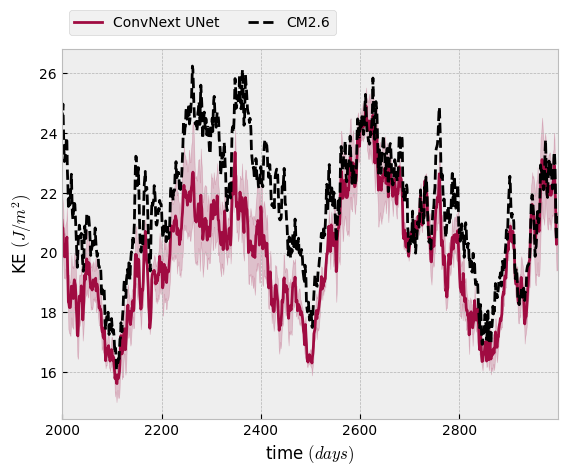

In [18]:
if args.N_test == 2000:
    plot_metrics_KE_seeds(
        e.pred_names + [e.network],
        e.region + '_Long_',
        e.str_save,
        e.output_dir,
        KE_true,
        KE_saved,
        999,
        1999
    )
else:
    plot_metrics_KE_seeds(
        e.pred_names + [e.network],
        e.region + '_Long_',
        e.str_save,
        e.output_dir,
        KE_true,
        KE_saved,
    )

In [30]:
np.save(Path(args.output_dir) / 'timeseries_KE_true', KE_true)
np.save(Path(args.output_dir) / 'timeseries_KE_saved', KE_saved)

#### Timeseries Temp

In [26]:
def get_timeseries_temperature(e, model_pred_net, model_pred_saved_nets, start=0, N_eval=200, N_eval_ACC=100, long=False):
    ### Spatial matching metrics
    print("Getting Spatial matching stats...")
    T_test = np.array(
        e.test_data[:][1][:, 2] * e.std_out[2] + e.mean_out[2]
    )
    
    print("Getting Mean...")
    
    mean_T_net_list = []
    mean_T_true_list = []

    for i in range(num_seeds):
        mean_T_net, mean_T_true = compute_mean_single(
            N_eval,
            T_test,
            model_pred_net[i][:, :, :, 2],
            e.area,
            e.wet_bool,
        )
        mean_T_net_list.append(mean_T_net)
        mean_T_true_list.append(mean_T_true)
    
    mean_T_net = np.stack(mean_T_net_list)
    mean_T_true = np.stack(mean_T_true_list)
    
    mean_T_saved = []
    
    for model_pred_saved in model_pred_saved_nets:
        mean_T_i_list = []
        
        for i in range(num_seeds):
            mean_T_i, _ = compute_mean_single(
                N_eval,
                T_test,
                model_pred_saved[i][:, :, :, 2],
                e.area,
                e.wet_bool,
            )
            mean_T_i_list.append(mean_T_i)
        
        mean_T_saved.append(np.stack(mean_T_i_list))

    return mean_T_true, mean_T_saved + [mean_T_net]


In [29]:
if args.N_test == 2000:
    T_true, T_saved = get_timeseries_temperature(e, model_pred_net, model_pred_saved_nets, start=999, N_eval=1999, long=True)
else:
    T_true, T_saved = get_timeseries_temperature(e, model_pred_net, model_pred_saved_nets, start=1999, N_eval=2999, long=True)

Getting Spatial matching stats...
Getting Mean...


In [21]:
def plot_metrics_T_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    T_true,
    Ts,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(T_true)

    rho = 1020
    for i, T_i in enumerate(Ts):
        if T_i is not None:
            plt.plot(
                np.arange(start, end),
                T_i.mean(axis=0)[start:end],
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(start, end),
                T_i.mean(axis=0)[start:end] - T_i.std(axis=0)[start:end],
                T_i.mean(axis=0)[start:end] + T_i.std(axis=0)[start:end],
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(np.arange(start, end), T_true.mean(axis=0)[start:end], "--k", color="dimgrey", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"$\overline{T}$ $( ^\circ C )$")
    plt.xlim([start, end])
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(Ts)+1)
    
    plt.show()
    
    # plt.savefig(
    #     Path(output_dir) / ("T" + region + "_" + save_str + ".png"),
    #     bbox_inches="tight",
    # )
    # plt.clf()
    

/state/partition1/job-47075721/ipykernel_869929/2207259521.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(np.arange(start, end), T_true.mean(axis=0)[start:end], "--k", color="dimgrey", label="CM2.6")


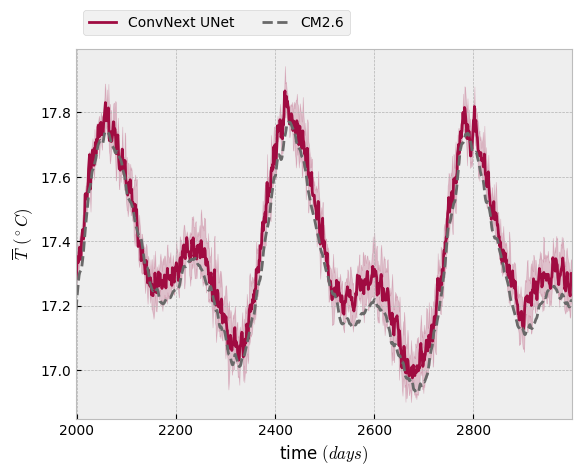

In [22]:
if args.N_test == 2000:
    plot_metrics_T_seeds(
            e.pred_names + [e.network],
            e.region + '_Long_',
            e.str_save,
            e.output_dir,
            T_true, 
            T_saved,
            999,
            1999
        )
else:
    plot_metrics_T_seeds(
            e.pred_names + [e.network],
            e.region + '_Long_',
            e.str_save,
            e.output_dir,
            T_true, 
            T_saved
        )

In [35]:
np.save(Path(args.output_dir) / 'timeseries_T_true', T_true)
np.save(Path(args.output_dir) / 'timeseries_T_saved', T_saved)

#### Indices

In [36]:
def plot_indices(e, model_pred_net, model_pred_saved_nets, long=False):
    print("Getting Nino34...")
    
    nino_net_list = []
    nino_true_list = []

    for i in range(num_seeds):
        nino_net, nino_true = compute_nino34(
            e.grids,
            e.inputs,
            model_pred_net[i], 
            e.test_data, 
            e.mean_out,
            e.std_out,
            e.time_test
        )
        nino_net_list.append(nino_net)
        nino_true_list.append(nino_true)
    
    nino_net = np.stack(nino_net_list)
    nino_true = np.stack(nino_true_list)
    
    nino_saved = []
    
    for model_pred_saved in model_pred_saved_nets:
        nino_net_i_list = []
        
        for i in range(num_seeds):
            nino_net_i, _ = compute_nino34(
                e.grids,
                e.inputs,
                model_pred_saved[i], 
                e.test_data, 
                e.mean_out,
                e.std_out,
                e.time_test
            )
            nino_net_i_list.append(nino_net_i)
        
        nino_saved.append(np.stack(nino_net_i_list))
    
    print("Getting Amo...")
    
    amo_net_list = []
    amo_true_list = []

    for i in range(num_seeds):
        amo_net, amo_true = compute_amo(
            e.grids,
            e.inputs,
            model_pred_net[i],
            e.test_data, 
            e.mean_out,
            e.std_out,
            e.time_test
        )
        amo_net_list.append(amo_net)
        amo_true_list.append(amo_true)
    
    amo_net = np.stack(amo_net_list)
    amo_true = np.stack(amo_true_list)
    
    amo_saved = []
    
    for model_pred_saved in model_pred_saved_nets:
        amo_net_i_list = []
        
        for i in range(num_seeds):
            amo_net_i, _ = compute_amo(
                e.grids,
                e.inputs,
                model_pred_saved[i],
                e.test_data, 
                e.mean_out,
                e.std_out,
                e.time_test
            )
            amo_net_i_list.append(amo_net_i)
        
        amo_saved.append(np.stack(amo_net_i_list))

    return nino_true, nino_saved + [nino_net], amo_true, amo_saved + [amo_net]


In [37]:
nino_true, nino_saved, amo_true, amo_saved = plot_indices(e, model_pred_net, model_pred_saved_nets, long=True)

Getting Nino34...
Getting Amo...


In [38]:
def plot_index(network_names,
    region,
    save_str,
    output_dir,
    true,
    indices,
    mode='nino34'):

    plt.style.use("bmh")

    clist = ["#3300EA","#D7191C","#DE7400","#00BD8E"]

    N_plot = len(indices[0][0])

    # Indices
    for i, indices_i in enumerate(indices):
        if indices_i is not None:
            plt.plot(
                np.arange(1, N_plot + 1),
                indices_i.mean(axis=0),
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(1, N_plot + 1),
                indices_i.mean(axis=0) - indices_i.std(axis=0),
                indices_i.mean(axis=0) + indices_i.std(axis=0),
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(np.arange(1, N_plot + 1), true.mean(axis=0), "--k", label="CM2.6")
    plt.xlabel(r"time $( days )$", fontsize="15")
    y = 'Nino 3.4 Index' if mode == 'nino34' else 'AMO Index'
    plt.ylabel(y, fontsize="15")
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, fontsize="15", ncol=len(indices)+1)
    
    # plt.show()
    
    plt.savefig(
        Path(output_dir) / (y + '_' + region + "_" + save_str + ".png"),
        bbox_inches="tight",
    )
    plt.clf()


In [39]:
print("Plotting Nino34...")
plot_index(
    e.pred_names + [e.network],
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    nino_true,
    nino_saved,
    mode='nino34'
)

print("Plotting Amo...")
plot_index(
    e.pred_names + [e.network],
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    amo_true,
    amo_saved,
    mode='amo'
)

Plotting Nino34...
Plotting Amo...


<Figure size 640x480 with 0 Axes>

In [40]:
np.save(Path(args.output_dir) / 'nino_true', nino_true)
np.save(Path(args.output_dir) / 'nino_saved', nino_saved)
np.save(Path(args.output_dir) / 'amo_true', amo_true)
np.save(Path(args.output_dir) / 'amo_saved', amo_saved)

#### PDF

In [41]:
def get_pdf(e, model_pred_net, model_pred_saved_nets, start=100, N_days=100, long=False):
    # PDF
    print("Getting PDF stats...")
    pdf = {}
    for ind_plot in range(3):
        true_field = (
            e.test_data[start : start + N_days][1][
                :, ind_plot, e.wet_bool
            ].flatten()
            * e.std_out[ind_plot]
        ) + e.mean_out[ind_plot]
        true_pdf, bins_true = np.histogram(true_field, bins=150, density=True)

        # Seeds
        bins_net_list = []
        pdf_net_list = []
    
        for i in range(num_seeds):        
            field_net = model_pred_net[i][
                start : start + N_days, e.wet_bool, ind_plot
            ].flatten()
            pdf_net, bins_net = np.histogram(field_net, bins=bins_true, density=True)
            bins_net = (bins_net[1:] + bins_net[:-1]) / 2

            bins_net_list.append(bins_net)
            pdf_net_list.append(pdf_net)

        bins_net = np.stack(bins_net_list)
        pdf_net = np.stack(pdf_net_list)
            

        pdf[ind_plot] = {
            "true_pdf": true_pdf,
            e.network: [bins_net, pdf_net],
        }

        for i, model_pred_saved in enumerate(model_pred_saved_nets):
            bins_i_list = []
            pdf_i_list = []
            for j in range(num_seeds):        
                field_i = model_pred_saved[j][
                    start : start + N_days, e.wet_bool, ind_plot
                ].flatten()
                pdf_i, bins_i = np.histogram(field_i, bins=bins_true, density=True)
                bins_i = (bins_i[1:] + bins_i[:-1]) / 2
    
                bins_i_list.append(bins_i)
                pdf_i_list.append(pdf_i)

            bins_i = np.stack(bins_i_list)
            pdf_i = np.stack(pdf_i_list)

            pdf[ind_plot][e.pred_names[i]] = [bins_i, pdf_i]

        bins_true = (bins_true[1:] + bins_true[:-1]) / 2
        pdf[ind_plot]["true"] = [bins_true, true_pdf]

    # KE PDF
    long_KE_net = []
    for i in range(num_seeds):        
        long_KE_neti, long_KE_true = gen_KE_range(
            start, N_days, e.test_data, model_pred_net[i]
        )
        long_KE_net.append(long_KE_neti)

    true_KE_field = long_KE_true[:, e.wet_bool].flatten()
    true_KE_pdf, bins_KE_true = np.histogram(true_KE_field, bins=150, density=True)

    # Seeds
    bins_net_list = []
    pdf_net_list = []

    for i in range(num_seeds):        
        field_KE_net = long_KE_net[i][:, e.wet_bool].flatten()
        pdf_KE_net, bins_KE_net = np.histogram(field_KE_net, bins=bins_KE_true, density=True)
        bins_KE_net = (bins_KE_net[1:] + bins_KE_net[:-1]) / 2

        bins_net_list.append(bins_KE_net)
        pdf_net_list.append(pdf_KE_net)

    bins_KE_net = np.stack(bins_net_list)
    pdf_KE_net = np.stack(pdf_net_list)
    
    pdf["KE"] = {
            "true_pdf": true_KE_pdf,
            e.network: [bins_KE_net, pdf_KE_net],
        }

    for i, model_pred_saved in enumerate(model_pred_saved_nets):
        bins_i_list = []
        pdf_i_list = []
        for j in range(num_seeds):
            long_KE_savedi, _ = gen_KE_range(
                start, N_days, e.test_data, model_pred_saved[j]
            )
            field_i = long_KE_savedi[:, e.wet_bool].flatten()
            pdf_i, bins_i = np.histogram(field_i, bins=bins_KE_true, density=True)
            bins_i = (bins_i[1:] + bins_i[:-1]) / 2

            bins_i_list.append(bins_i)
            pdf_i_list.append(pdf_i)
        
        bins_i = np.stack(bins_i_list)
        pdf_i = np.stack(pdf_i_list)
        
        pdf["KE"][e.pred_names[i]] = [bins_i, pdf_i]

    bins_KE_true = (bins_KE_true[1:] + bins_KE_true[:-1]) / 2
    pdf["KE"]["true"] = [bins_KE_true, true_KE_pdf]

    return pdf

In [42]:
if args.N_test == 2000:
    pdf = get_pdf(e, model_pred_net, model_pred_saved_nets, start=999, N_days=1000, long=True)
else:
    pdf = get_pdf(e, model_pred_net, model_pred_saved_nets, start=1999, N_days=1000, long=True)

Getting PDF stats...


In [43]:
def plot_metrics_pdf(
    network_names,
    region,
    output_dir,
    pdf,
    JUPYTER_MODE=False,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    # PDF
    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $( m/s )$",
        "2": r"$\overline{T}$ $( ^\circ C )$",
        "KE": r"$\overline{KE}$",
    }

    for ind_plot in pdf.keys():
        for i, network_name in enumerate(network_names):
            plt.semilogy(
                pdf[ind_plot][network_name][0].mean(axis=0),
                pdf[ind_plot][network_name][1].mean(axis=0),
                lw=2,
                color=clist[i],
                label=f"{network_name}",
            )
            plt.fill_between(
                pdf[ind_plot][network_name][0].mean(axis=0),
                pdf[ind_plot][network_name][1].mean(axis=0) - pdf[ind_plot][network_name][1].std(axis=0),
                pdf[ind_plot][network_name][1].mean(axis=0) + pdf[ind_plot][network_name][1].std(axis=0),
                ls="-",
                color=clist[i],
                alpha=0.2,
            )
            

        if ind_plot != 2:
            plt.ylim(
                [
                    pdf[ind_plot]["true_pdf"].min(),
                    pdf[ind_plot]["true_pdf"].max(),
                ]
            )
        else:
            plt.ylim(
                [
                    0.01,
                    pdf[ind_plot]["true_pdf"].max(),
                ]
            )
        
        if ind_plot == 2:
            plt.xlim(
                [
                    -3,32
                ]
            )
        elif ind_plot == "KE":
            plt.xlim(
                [
                    0,
                    2500
                ]
            )

        plt.semilogy(pdf[ind_plot]["true"][0], pdf[ind_plot]["true"][1], lw=2, c="k", ls='--', label="CM2.6")
        plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(pdf[0].keys()))
        

        plt.xlabel(var_list[str(ind_plot)])
        if isinstance(ind_plot, int): 
            plt.ylabel(r"${p(}$" + var_list[str(ind_plot)][:14] + "${)}$")
        else:
            plt.ylabel(r"${p(}$" + var_list[str(ind_plot)] + "${)}$")


        if JUPYTER_MODE:
            plt.show()

        else:
            plt.savefig(
                Path(output_dir) / ("PDF" + region + "_" + str(ind_plot) + ".png"),
                bbox_inches="tight",
            )
            plt.clf()

In [44]:
print("Plotting pdf...")
plot_metrics_pdf(
    e.pred_names + [e.network],
    e.region + '_Long_',
    e.output_dir,
    pdf,
    e.JUPYTER_MODE
)

Plotting pdf...


/state/partition1/job-46954704/ipykernel_232459/3696844915.py:40: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(


<Figure size 640x480 with 0 Axes>

In [45]:
np.save(Path(args.output_dir) / 'pdf', pdf)

#### Animation (u/v/T)

In [43]:
def compute_rmse_snapshot(test_data, model_pred, area, wet, mean, std, index):
    area_flat = np.array(area[wet].flatten())

    truth = test_data[index, wet] * std[index] + mean[index]

    truth = np.array(truth.cpu())

    rmse_u = np.sqrt(
        (
            area_flat
            * (model_pred[wet, index].flatten() - truth.flatten()) ** 2
        ).sum()
        / area_flat.sum()
    )

    return rmse_u

def get_stats(
    zarr_path,
    region,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_mean,
    index,
):
    mean_out = test_data.norm_vals["m_out"]
    std_out = test_data.norm_vals["s_out"]
    rmse = 1e7
    test_time = 25
    for rand_int in range(1, 4):
        model_pred_temp = (
            xr.open_zarr(
                zarr_path
                / (
                    "Pred_lateral_Fast_Data_025_"
                    + region
                    + "_in_"
                    + str_in
                    + "ext_"
                    + str_ext
                    + "N_samples_"
                    + str(e.N_samples)
                    + "_rand_seed_"
                    + str(rand_int)
                    + ".zarr"
                )
            )
            .sel(time=slice(test_time - 1, test_time))
            .to_array()
            .to_numpy()
            .squeeze()
        )
        rmse_temp = compute_rmse_snapshot(
            test_data[test_time - 1][1],
            model_pred_temp,
            area,
            wet_bool,
            mean_out,
            std_out,
            index,
        )
        print("RMSE: ", rmse_temp)
        if rmse_temp < rmse:
            print("Best RMSE...")
            rmse = rmse_temp
            rand_best = rand_int
            
    model_pred_atm = (
        xr.open_zarr(
            zarr_path
            / (
                "Pred_lateral_Fast_Data_025_"
                + region
                + "_in_"
                + str_in
                + "ext_"
                + str_ext
                + "N_samples_"
                + str(e.N_samples)
                + "_rand_seed_"
                + str(rand_best)
                + ".zarr"
            )
        )
        .sel(time=slice(0, N_mean))
        .to_array()
        .to_numpy()
        .squeeze()
    )
    return model_pred_atm, rand_best

In [44]:
print("Plot animation begin...")

N_plot = 1500
ind_plot = 2

print("Collecting stats: ", e.network)
model_pred_net, rand_best = get_stats(
    e.pred_model_path,
    e.region,
    e.str_in,
    e.str_ext,
    e.test_data,
    e.area,
    e.wet_bool,
    N_plot,
    ind_plot,
)

model_pred_saved_nets = []
for i, model_pred_path in enumerate(e.pred_paths):
    print("Collecting stats: ", e.pred_names[i])
    model_pred_i, _ = get_stats(
        Path(model_pred_path),
        e.pred_region,
        e.str_in,
        e.str_ext,
        e.test_data,
        e.area,
        e.wet_bool,
        N_plot,
        ind_plot,
    )
    model_pred_saved_nets.append(model_pred_i)

    # torch.save(model_pred_unet, f'model_pred_{ind_plot}.pt')

model_pred_saved_nets.append(model_pred_net)

Plot animation begin...
RMSE:  0.756721844960808
Best RMSE...
RMSE:  0.7524390249350403
Best RMSE...
RMSE:  0.7493718372802455
Best RMSE...


In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

def get_initial_snapshot_fig(
    network_names,
    N_plot,
    region,
    grids,
    test_data,
    wet_nan,
    model_preds,
    mean_out,
    std_out,
    ind_plot,
    Nb,
):

    plt.rcParams.update({"font.size": 12})
    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $(m/s)$",
        "2": r"Temperature $( ^\circ C )$",
    }
    if len(model_preds) > 1:
        fig, axs = plt.subplots(
            2,
            3,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.25,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    elif len(model_preds) == 1:
        fig, axs = plt.subplots(
            2,
            2,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.1,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    else:
        print("0 entries in model_preds")
        return

    T_plot = N_plot

    vmin = mean_out[ind_plot] - std_out[ind_plot]
    vmax = mean_out[ind_plot] + std_out[ind_plot]

    if region == "Tropics_Ext" and ind_plot == 2:
        vmin = mean_out[ind_plot] - (0.5 * std_out[ind_plot])
        vmax = mean_out[ind_plot] + (std_out[ind_plot])
    elif region == "Africa_Ext" and ind_plot == 2:
        vmin = mean_out[ind_plot] - (1.25 * std_out[ind_plot])
        vmax = mean_out[ind_plot] + (2 * std_out[ind_plot])
    elif region == "Gulf_Stream_Ext" and ind_plot == 2:
        vmin = mean_out[ind_plot] - (1.75 * std_out[ind_plot])
        vmax = mean_out[ind_plot] + (1.75 * std_out[ind_plot])
    elif ind_plot == 2:
        vmax = 30

    if ind_plot in [0, 1]:
        vmin -= std_out[ind_plot]
        vmax += std_out[ind_plot]
        limit = np.round(np.max([abs(vmin), abs(vmax)]), 1)
        vmin = -limit
        vmax = limit

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    if ind_plot == 2:
        cmap = cmocean.cm.thermal
    else:
        cmap = cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            test_data[N_plot - 1][1][ind_plot].cpu() * wet_nan * std_out[ind_plot]
            + mean_out[ind_plot],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            test_data[N_plot - 1][1][ind_plot, Nb:-Nb, Nb:-Nb].cpu()
            * wet_nan[Nb:-Nb, Nb:-Nb]
            * std_out[ind_plot]
            + mean_out[ind_plot],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title(r"CM2.6", size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    if len(model_preds) > 1:
        new_pos = [
            pos.x0 - 0.42,
            pos.y0 - 0.1,
            pos.width * 1.75,
            pos.height * 1.5,
        ]  # Adjust 0.2 as needed
    else:
        new_pos = [
            pos.x0 - 0.55,
            pos.y0 - 0.1,
            pos.width * 1.75,
            pos.height * 1.5,
        ]  # Adjust 0.2 as needed
    

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=12)  # Set the font size for tick labels
    if ind_plot == 2:
        cbar.set_ticks([np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)])
    else:
        cbar.set_ticks([vmin, 0, vmax])

    cbar.ax.set_title(var_list[str(ind_plot)], fontsize=12, loc='left', pad = 10)

    fig.delaxes(cax)

    plts = [plt0]
    for i, model_pred in enumerate(model_preds):
        if model_pred is not None:
            if i == 0:
                idy, idx = 0, 1
            elif i == 1:
                idy, idx = 0, 2
            elif i == 2:
                idy, idx = 1, 1
            elif i == 3:
                idy, idx = 1, 2

            if "global" in region:
                plt_temp = axs[idy, idx].pcolormesh(
                    x_plot,
                    y_plot,
                    model_pred[T_plot - 1, :, :, ind_plot] * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_temp = axs[idy, idx].pcolormesh(
                    x_plot,
                    y_plot,
                    model_pred[T_plot - 1, Nb:-Nb, Nb:-Nb, ind_plot]
                    * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[idy, idx].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[idy, idx].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[idy, idx].set_title(network_names[i], size=15)
            plts.append(plt_temp)

    axs[1, 0].set_axis_off()
    if len(model_preds) == 1:
        axs[1, 1].set_axis_off()
    if len(model_preds) == 2:
        axs[1, 1].set_axis_off()
        axs[1, 2].set_axis_off()
    if len(model_preds) == 3:
        axs[1, 2].set_axis_off()

    region_title = ""

    for i in region:
        if region == "Quiescent_Ext":
            region_title = "South Pacific"
        elif region == "Africa_Ext":
            region_title = "African Cape"
        elif i == "_":
            region_title += " "
        elif i == "E":
            break
        else:
            region_title += i
    region_title = str(region_title)

    a = fig.suptitle(
        r"$t = " + str(N_plot) + "$ days ",
        fontsize=16,
    )
    return fig, plts, a

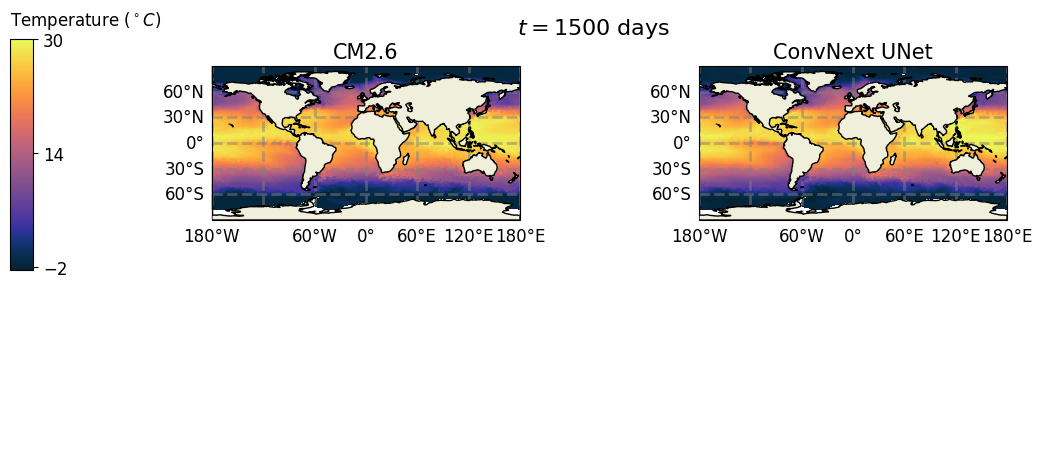

In [46]:
var_list = {"1": r"v", "0": r"u", "2": r"T"}
networks = e.pred_names + [e.network]
networks = networks
model_pred_saved_nets_removed = model_pred_saved_nets
fig, plts, a = get_initial_snapshot_fig(
    networks,
    N_plot,
    e.region,
    e.grids,
    e.test_data,
    e.wet_nan,
    model_pred_saved_nets_removed,
    e.mean_out,
    e.std_out,
    ind_plot,
    e.Nb,
)

In [29]:
def update_snapshot(i):
    print("Frame : ", i)
    plts[0].set_array(
        (
            e.test_data[i][1][ind_plot].cpu()
            * e.wet_nan
            * e.std_out[ind_plot]
            + e.mean_out[ind_plot]
        ).flatten()
    )
    for j, model_pred in enumerate(model_pred_saved_nets_removed):
        plts[j + 1].set_array(
            (model_pred[i, :, :, ind_plot] * e.wet_nan).flatten()
        )
    a.set_text(r"$t = " + str(i + 1) + "$ days ")

In [30]:
var_list = {"1": r"v", "0": r"u", "2": r"T", "KE": r"KE"}
anim = FuncAnimation(
    fig, update_snapshot, interval=100, frames=range(0, 1500, 2)
)
anim.save(
    (
        f'./temp/seed_{rand_best}'
        + e.post_model_name
        + "_"
        + e.region
        + "_"
        + var_list[str(ind_plot)]
        + ".gif"
    )
)

MovieWriter ffmpeg unavailable; using Pillow instead.


Frame :  0
Frame :  0
Frame :  2
Frame :  4
Frame :  6
Frame :  8
Frame :  10
Frame :  12
Frame :  14
Frame :  16
Frame :  18
Frame :  20
Frame :  22
Frame :  24
Frame :  26
Frame :  28
Frame :  30
Frame :  32
Frame :  34
Frame :  36
Frame :  38
Frame :  40
Frame :  42
Frame :  44
Frame :  46
Frame :  48
Frame :  50
Frame :  52
Frame :  54
Frame :  56
Frame :  58
Frame :  60
Frame :  62
Frame :  64
Frame :  66
Frame :  68
Frame :  70
Frame :  72
Frame :  74
Frame :  76
Frame :  78
Frame :  80
Frame :  82
Frame :  84
Frame :  86
Frame :  88
Frame :  90
Frame :  92
Frame :  94
Frame :  96
Frame :  98
Frame :  100
Frame :  102
Frame :  104
Frame :  106
Frame :  108
Frame :  110
Frame :  112
Frame :  114
Frame :  116
Frame :  118
Frame :  120
Frame :  122
Frame :  124
Frame :  126
Frame :  128
Frame :  130
Frame :  132
Frame :  134
Frame :  136
Frame :  138
Frame :  140
Frame :  142
Frame :  144
Frame :  146
Frame :  148
Frame :  150
Frame :  152
Frame :  154
Frame :  156
Frame :  158
Fram

#### Animation (KE)

In [26]:
def get_stats(
    zarr_path,
    region,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_mean,
):
    mean_out = test_data.norm_vals["m_out"]
    std_out = test_data.norm_vals["s_out"]
    rmse = 1e7
    for rand_int in range(1, 4):
        model_pred_temp = (
            xr.open_zarr(
                zarr_path
                / (
                    "Pred_lateral_Fast_Data_025_"
                    + region
                    + "_in_"
                    + str_in
                    + "ext_"
                    + str_ext
                    + "N_samples_"
                    + str(e.N_samples)
                    + "_rand_seed_"
                    + str(rand_int)
                    + ".zarr"
                )
            )
            .to_array()
            .to_numpy()
            .squeeze()
        )

        long_KE_net, long_KE_true = gen_KE_range(
            0, N_mean, test_data, model_pred_temp
        )

        print(long_KE_net.shape)
        print(long_KE_true.shape)

        rmse_KE = np.sqrt(((long_KE_net - long_KE_true)**2).mean())
        
        print("RMSE: ", rmse_KE)
        if rmse_KE < rmse:
            print("Best RMSE...")
            rmse = rmse_KE
            rand_best = rand_int
            long_KE_best = long_KE_net
            
    return long_KE_best, long_KE_true, rand_best

In [27]:
print("Plot animation begin...")

N_plot = 1500
ind_plot = 'KE'

print("Collecting stats: ", e.network)
long_KE_best, long_KE_true, rand_best = get_stats(
    e.pred_model_path,
    e.region,
    e.str_in,
    e.str_ext,
    e.test_data,
    e.area,
    e.wet_bool,
    N_plot,
)

model_pred_saved_nets = []
for i, model_pred_path in enumerate(e.pred_paths):
    print("Collecting stats: ", e.pred_names[i])
    long_KE_best_i, _, _ = get_stats(
        Path(model_pred_path),
        e.pred_region,
        e.str_in,
        e.str_ext,
        e.test_data,
        e.area,
        e.wet_bool,
        N_plot,
    )
    model_pred_saved_nets.append(long_KE_best_i)

model_pred_saved_nets.append(long_KE_best)

Plot animation begin...
(1500, 180, 360)
(1500, 180, 360)
RMSE:  33.728093530517704
Best RMSE...
(1500, 180, 360)
(1500, 180, 360)
RMSE:  33.26660514963738
Best RMSE...
(1500, 180, 360)
(1500, 180, 360)
RMSE:  34.065750590033225
(1500, 180, 360)
(1500, 180, 360)
RMSE:  39.59030960321181
Best RMSE...
RMSE:  36.306615958197106
Best RMSE...
(1500, 180, 360)
(1500, 180, 360)
RMSE:  36.27835354424707
Best RMSE...
(1500, 180, 360)
(1500, 180, 360)
RMSE:  36.9556529609157
Best RMSE...
(1500, 180, 360)
(1500, 180, 360)
RMSE:  38.80690691985434
(1500, 180, 360)
(1500, 180, 360)
RMSE:  36.8956824383821
Best RMSE...
(1500, 180, 360)
(1500, 180, 360)
RMSE:  34.8032381471066
Best RMSE...
(1500, 180, 360)
(1500, 180, 360)
RMSE:  34.93153320873502
(1500, 180, 360)
(1500, 180, 360)
RMSE:  35.699152235282234


In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

def get_initial_snapshot_fig(
    network_names,
    N_plot,
    region,
    grids,
    test_data,
    wet_nan,
    model_preds,
    mean_out,
    std_out,
    Nb,
):
    plt.rcParams.update({"font.size": 12})
    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $(m/s)$",
        "2": r"Temperature $( ^\circ C )$",
        "KE": r"Kinetic Energy $( J/m^2 )$"
    }
    if len(model_preds) > 1:
        fig, axs = plt.subplots(
            2,
            3,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.25,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    elif len(model_preds) == 1:
        fig, axs = plt.subplots(
            2,
            2,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.1,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    else:
        print("0 entries in model_preds")
        return

    T_plot = N_plot

    vmin = 0
    vmax = 60

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal

    # Ground Truth
    plt0 = axs[0, 0].pcolormesh(
        x_plot,
        y_plot,
        long_KE_true[N_plot-1],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="auto",
    )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title(r"CM2.6", size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    if len(model_preds) > 1:
        new_pos = [
            pos.x0 - 0.42,
            pos.y0 - 0.1,
            pos.width * 1.75,
            pos.height * 1.5,
        ]  # Adjust 0.2 as needed
    else:
        new_pos = [
            pos.x0 - 0.55,
            pos.y0 - 0.1,
            pos.width * 1.75,
            pos.height * 1.5,
        ]  # Adjust 0.2 as needed
    

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="vertical", aspect=10)
    cbar.ax.tick_params(labelsize=12)  # Set the font size for tick labels
    cbar.set_ticks([np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)])

    cbar.ax.set_title(var_list[str(ind_plot)], fontsize=12, loc='left', pad = 10)

    fig.delaxes(cax)

    plts = [plt0]
    for i, model_pred in enumerate(model_preds):
        if model_pred is not None:
            if i == 0:
                idy, idx = 0, 1
            elif i == 1:
                idy, idx = 0, 2
            elif i == 2:
                idy, idx = 1, 1
            elif i == 3:
                idy, idx = 1, 2

            plt_temp = axs[idy, idx].pcolormesh(
                x_plot,
                y_plot,
                model_pred[T_plot - 1],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                shading="auto",
            )

            axs[idy, idx].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[idy, idx].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[idy, idx].set_title(network_names[i], size=15)
            plts.append(plt_temp)

    axs[1, 0].set_axis_off()
    if len(model_preds) == 1:
        axs[1, 1].set_axis_off()
    if len(model_preds) == 2:
        axs[1, 1].set_axis_off()
        axs[1, 2].set_axis_off()
    if len(model_preds) == 3:
        axs[1, 2].set_axis_off()

    region_title = ""

    for i in region:
        if region == "Quiescent_Ext":
            region_title = "South Pacific"
        elif region == "Africa_Ext":
            region_title = "African Cape"
        elif i == "_":
            region_title += " "
        elif i == "E":
            break
        else:
            region_title += i
    region_title = str(region_title)

    a = fig.suptitle(
        r"$t = " + str(N_plot) + "$ days ",
        fontsize=16,
    )
    return fig, plts, a

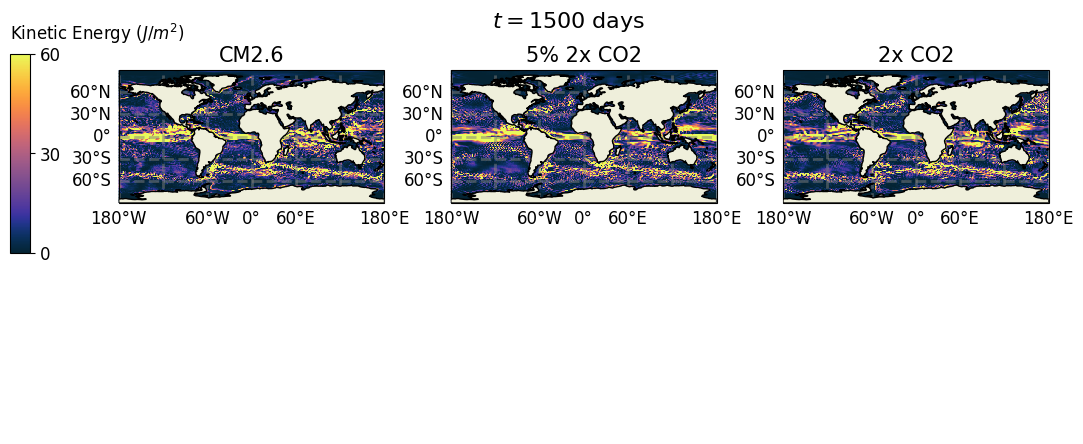

In [32]:
var_list = {"1": r"v", "0": r"u", "2": r"T", "KE": r"KE"}
networks = e.pred_names + [e.network]
networks = networks[2:]
model_pred_saved_nets_removed = model_pred_saved_nets[2:]
fig, plts, a = get_initial_snapshot_fig(
    networks,
    N_plot,
    e.region,
    e.grids,
    e.test_data,
    e.wet_nan,
    model_pred_saved_nets_removed,
    e.mean_out,
    e.std_out,
    e.Nb,
)

In [33]:
def update_snapshot(i):
    print("Frame : ", i)
    plts[0].set_array(
        (
            long_KE_true[i]
        ).flatten()
    )
    for j, model_pred in enumerate(model_pred_saved_nets_removed):
        plts[j + 1].set_array(
            (model_pred[i]).flatten()
        )
    a.set_text(r"$t = " + str(i + 1) + "$ days ")

In [34]:
var_list = {"1": r"v", "0": r"u", "2": r"T", "KE": r"KE"}
anim = FuncAnimation(
    fig, update_snapshot, interval=100, frames=range(0, 1500, 2)
)
anim.save(
    (
        f'./temp/KE_seed_{rand_best}'
        + e.post_model_name
        + "_"
        + e.region
        + "_"
        + var_list[str(ind_plot)]
        + ".gif"
    )
)

MovieWriter ffmpeg unavailable; using Pillow instead.


Frame :  0
Frame :  0
Frame :  2
Frame :  4
Frame :  6
Frame :  8
Frame :  10
Frame :  12
Frame :  14
Frame :  16
Frame :  18
Frame :  20
Frame :  22
Frame :  24
Frame :  26
Frame :  28
Frame :  30
Frame :  32
Frame :  34
Frame :  36
Frame :  38
Frame :  40
Frame :  42
Frame :  44
Frame :  46
Frame :  48
Frame :  50
Frame :  52
Frame :  54
Frame :  56
Frame :  58
Frame :  60
Frame :  62
Frame :  64
Frame :  66
Frame :  68
Frame :  70
Frame :  72
Frame :  74
Frame :  76
Frame :  78
Frame :  80
Frame :  82
Frame :  84
Frame :  86
Frame :  88
Frame :  90
Frame :  92
Frame :  94
Frame :  96
Frame :  98
Frame :  100
Frame :  102
Frame :  104
Frame :  106
Frame :  108
Frame :  110
Frame :  112
Frame :  114
Frame :  116
Frame :  118
Frame :  120
Frame :  122
Frame :  124
Frame :  126
Frame :  128
Frame :  130
Frame :  132
Frame :  134
Frame :  136
Frame :  138
Frame :  140
Frame :  142
Frame :  144
Frame :  146
Frame :  148
Frame :  150
Frame :  152
Frame :  154
Frame :  156
Frame :  158
Fram

#### sensitivity

In [8]:
e.pred_names

[]

In [33]:
def plot_metrics_KE_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    KE_true,
    KEs,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(KE_true)

    # KE
    rho = 1020
    for i, KE_i in enumerate(KEs):
        # if i == 0 or i == 1:
        #     continue
        if KE_i is not None:
            plt.plot(
                np.arange(start, end),
                KE_i[0][start:end] * rho,
                c=clist[0],
                label=f"{network_names[i]+ '_0'}",
            )
            plt.plot(
                np.arange(start, end),
                KE_i[1][start:end] * rho,
                c=clist[1],
                label=f"{network_names[i]+ '_1'}",
            )
            plt.plot(
                np.arange(start, end),
                KE_i[2][start:end] * rho,
                c=clist[2],
                label=f"{network_names[i]+ '_2'}",
            )

    plt.plot(np.arange(start, end), KE_true.mean(axis=0)[start:end] * rho, "--k", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"KE $( J/m^2 )$")
    plt.xlim([start, end])
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(KEs)+1)
    plt.show()
    

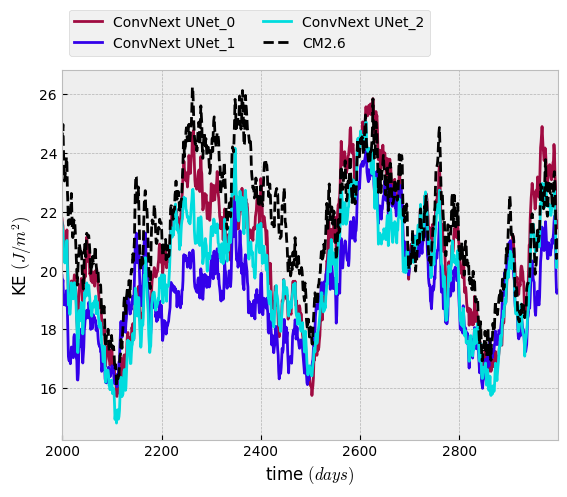

In [34]:
plot_metrics_KE_seeds(
        e.pred_names + [e.network],
        e.region + '_Long_',
        e.str_save,
        e.output_dir,
        KE_true,
        KE_saved,
    )

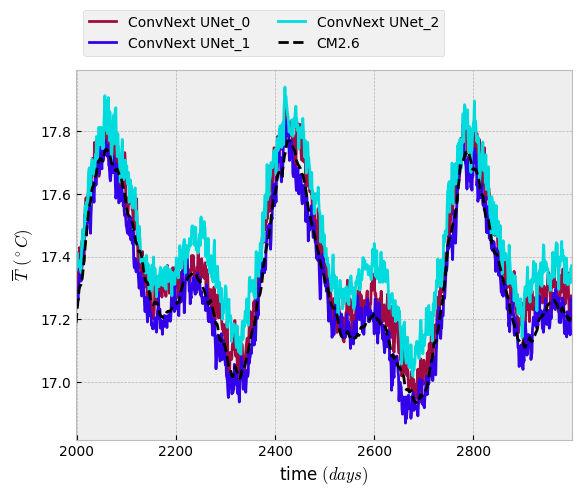

In [32]:
def plot_metrics_T_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    T_true,
    Ts,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(T_true)

    rho = 1020
    for i, T_i in enumerate(Ts):
        # if i == 0 or i == 1:
        #     continue
        if T_i is not None:
            plt.plot(
                np.arange(start, end),
                T_i[0][start:end],
                c=clist[0],
                label=f"{network_names[i] + '_0'}",
            )
            plt.plot(
                np.arange(start, end),
                T_i[1][start:end],
                c=clist[1],
                label=f"{network_names[i] + '_1'}",
            )
            plt.plot(
                np.arange(start, end),
                T_i[2][start:end],
                c=clist[2],
                label=f"{network_names[i] + '_2'}",
            )
            
    plt.plot(np.arange(start, end), T_true.mean(axis=0)[start:end], "--k", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"$\overline{T}$ $( ^\circ C )$")
    plt.xlim([start, end])
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(Ts)+1)
    
    plt.show()
    
    
plot_metrics_T_seeds(
        e.pred_names + [e.network],
        e.region + '_Long_',
        e.str_save,
        e.output_dir,
        T_true, 
        T_saved
    )